In [27]:
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from neurodsp.spectral import compute_spectrum
from neurodsp.filt import filter_signal
import os
from joblib import Parallel, delayed
from tqdm import tqdm
import torch
import scipy

from dynamix.model.forecaster import DynaMixForecaster
from dynamix.utilities.plotting_eval import plot_TS_forecast, plot_3D_attractor
from dynamix.utilities.utilities import load_hf_model

In [28]:
# define file paths
eeg_path = '/oscar/data/sjones/shared/TDBRAIN_preprocessed/preprocessed'
metadata_path = '../data/TDBRAIN_participants_V2.tsv'
subj_list = os.listdir(eeg_path)
print("Number of total subjects:", len(subj_list))

# read data
metadata_df = pd.read_csv(metadata_path, delimiter='\t')

# generate mask to pull out MDD, DISC subjects only
subj_mask = np.isin(metadata_df['participants_ID'].values, subj_list)
discovery_mask = metadata_df['DISC/REP'].values == 'DISCOVERY'
dataset_mask = metadata_df['Dataset'].values == 'MDD-rTMS'
rTMS_mask = ~metadata_df['rTMS PROTOCOL'].isna() # excludes 1 participant

mask = np.logical_and.reduce([subj_mask, discovery_mask, dataset_mask, rTMS_mask])

df = metadata_df[mask].copy() # .copy because plan to add columns later
df['age']  = df['age'].str.replace(',', '.').astype(float) # convert age to float
print("Shape after keeping MDD-rTMS, Discovery rows:", df.shape)

duplicate_ids = df["participants_ID"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1].index
df = df.drop_duplicates(subset="participants_ID", keep="first")
print("Shape after keeping only first entry for each participant:", df.shape)

# save paths to eeg numpy files for each subject in df
ec_eeg_path, eo_eeg_path, has_ses1 = list(), list(), list()

for subj_id in df['participants_ID'].values:
    subj_path = f'{eeg_path}/{subj_id}/ses-1/eeg'
    if os.path.isdir(subj_path):
        has_ses1.append(True)
        subj_files = os.listdir(subj_path)
        ec_subj_files = list(pathlib.Path(subj_path).glob('*restEC*.npy'))
        eo_subj_files = list(pathlib.Path(subj_path).glob('*restEO*.npy'))
        assert len(ec_subj_files) == len(eo_subj_files) == 1

        ec_eeg_path.append(str(ec_subj_files[0]))
        eo_eeg_path.append(str(eo_subj_files[0]))

    else:
        has_ses1.append(False)
        ec_eeg_path.append('')
        eo_eeg_path.append('')

df['ec_eeg_path'] = ec_eeg_path
df['eo_eeg_path'] = eo_eeg_path
df['has_ses1'] = has_ses1

df = df[df['has_ses1'] == True].reset_index(drop=True)
print("Shape after removing subj with no session 1 data:", df.shape)

# load the pre-trained model
model = load_hf_model("dynamix-6d-alrnn-v1.0")

# set model to evaluation mode
model.eval()

# initialize the forecaster
forecaster = DynaMixForecaster(model)

Number of total subjects: 1274
Shape after keeping MDD-rTMS, Discovery rows: (131, 111)
Shape after keeping only first entry for each participant: (123, 111)
Shape after removing subj with no session 1 data: (120, 114)


In [43]:
offset = 5000
CL = 10000
T = 20000

def get_dynamix_forecast(subj_data_path):

    channel_filter = ['F7', 'P8', 'T7', 'O2']
    # channel_filter = ['Fp1','Fz', 'F4', 'O1', 'Oz', 'O2',]

    eeg_dict = np.load(subj_data_path, allow_pickle=True)
    channel_labels = eeg_dict['labels']
    sampling_freq = eeg_dict['Fs']

    channel_mask = np.isin(channel_labels, channel_filter)
    eeg_data = eeg_dict['data'][0, channel_mask, :]
    assert eeg_data.shape[0] == len(channel_filter)


    context_start = offset
    context_end = offset + CL

    # Load the time series data
    eeg_data = filter_signal(eeg_data, fs=500, pass_type='bandpass', f_range=(1,200))

    ts_data = eeg_data.T

    context_ts = ts_data[context_start:context_end,:] # context from 5000 to 15000 (10s-30s)
    context_ts = scipy.signal.resample(context_ts, CL * 4, axis=0)

    # Convert to PyTorch tensor
    context_ts_tensor = torch.tensor(context_ts, dtype=torch.float32)
    
    # Make prediction
    with torch.no_grad():  # No gradient tracking needed for inference
        reconstruction_ts = forecaster.forecast(
            context=context_ts_tensor,
            horizon=T,
            preprocessing_method="pos_embedding",
            standardize=True,
            fit_nonstationary=False,
        )

    return ts_data[context_start:], context_ts, reconstruction_ts.numpy()

# extract features in parallel for all subjects
ec_res = Parallel(n_jobs=16)(delayed(get_dynamix_forecast)(ec_path) for ec_path in tqdm(df['ec_eeg_path'].values[:10]))
eo_res = Parallel(n_jobs=16)(delayed(get_dynamix_forecast)(ec_path) for ec_path in tqdm(df['eo_eeg_path'].values[:10]))



100%|██████████| 10/10 [00:00<00:00, 18063.32it/s]


In [44]:
subj_idx = 1
fs = 500 * 2

ground_truth_eo, context_eo, forecast_eo = eo_res[subj_idx]
ground_truth_ec, context_ec, forecast_ec = ec_res[subj_idx]


freqs, context_spectrum_ec = compute_spectrum(context_ec.T, fs=fs)
_, forecast_spectrum_ec = compute_spectrum(forecast_ec.T, fs=fs)

_ , context_spectrum_eo = compute_spectrum(context_eo.T, fs=fs)
_, forecast_spectrum_eo = compute_spectrum(forecast_eo.T, fs=fs)

freq_min, freq_max = 0, 50
freq_mask = np.logical_and(freqs < freq_max, freqs > freq_min)



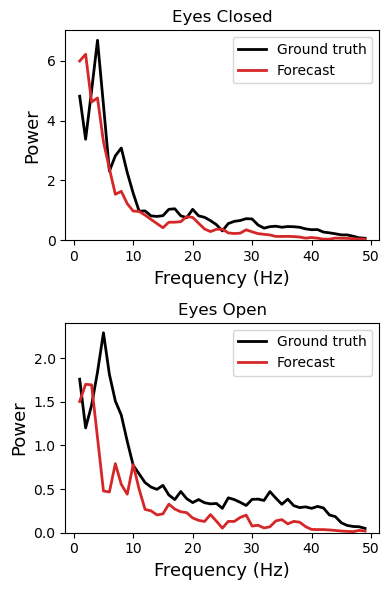

In [45]:
gt_color = 'k'
forecast_color = 'C3'
ymin, ymax = 0, None


label_size = 13
tick_size = 10
legend_size = 10
channel_idx = 0

plt.figure(figsize=(4,6))
plt.subplot(2,1,1)
plt.plot(freqs[freq_mask], context_spectrum_ec[channel_idx, freq_mask], label='Ground truth', color=gt_color, linewidth=2)
plt.plot(freqs[freq_mask], forecast_spectrum_ec[channel_idx, freq_mask], label='Forecast', color=forecast_color, linewidth=2)
plt.xlabel('Frequency (Hz)', fontsize=label_size)
plt.ylabel('Power', fontsize=label_size)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.legend(fontsize=legend_size)
plt.ylim(ymin, ymax)
plt.title('Eyes Closed')

plt.subplot(2,1,2)
plt.plot(freqs[freq_mask], context_spectrum_eo[channel_idx, freq_mask], label='Ground truth', color=gt_color, linewidth=2)
plt.plot(freqs[freq_mask], forecast_spectrum_eo[channel_idx, freq_mask], label='Forecast', color=forecast_color, linewidth=2)
plt.xlabel('Frequency (Hz)', fontsize=label_size)
plt.ylabel('Power', fontsize=label_size)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.legend(fontsize=legend_size)
plt.ylim(ymin, ymax)
plt.title('Eyes Open')
plt.tight_layout()

(array([-60., -40., -20.,   0.,  20.,  40.,  60.]),
 [Text(0, -60.0, '−60'),
  Text(0, -40.0, '−40'),
  Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60')])

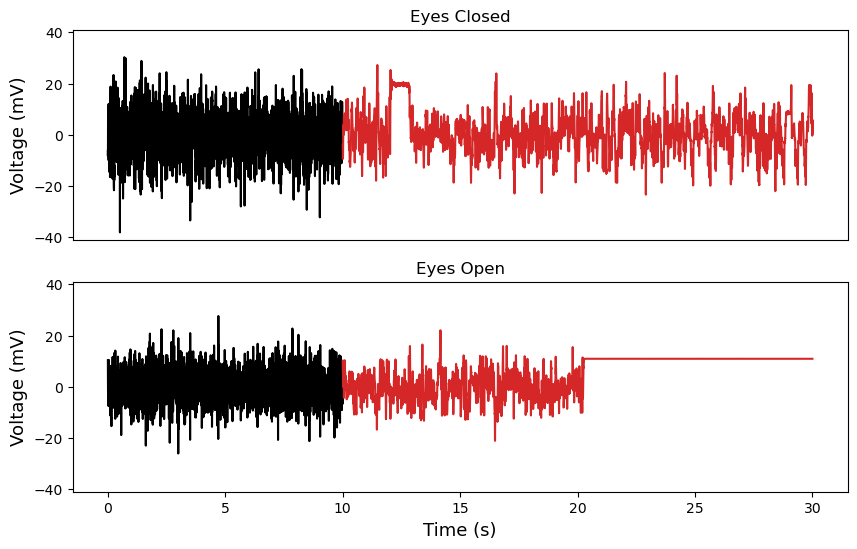

In [46]:
ts_min, ts_max = None, None
voltage_min, voltage_max = -41, 41

context_times = np.linspace(0, CL / fs, context_ec.shape[0]) 
forecast_times = np.linspace(CL / fs, (CL+T) / fs, forecast_ec.shape[0])
ground_truth_times = np.linspace(0, (CL+T) / fs, forecast_ec.shape[0])

plt.figure(figsize=(10, 6))
plt.subplot(2,1,1)
plt.plot(context_times, context_ec[:, channel_idx], color=gt_color)
plt.plot(forecast_times, forecast_ec[:, channel_idx], color=forecast_color)
plt.xlim(ts_min, ts_max)
plt.ylim(voltage_min, voltage_max)
plt.title('Eyes Closed')
plt.ylabel('Voltage (mV)', fontsize=label_size)
plt.xticks([], fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.subplot(2,1,2)
plt.plot(context_times, context_eo[:, channel_idx], color=gt_color)
plt.plot(forecast_times, forecast_eo[:, channel_idx], color=forecast_color)
plt.title('Eyes Open')
plt.ylabel('Voltage (mV)', fontsize=label_size)
plt.xlabel('Time (s)', fontsize=label_size)
plt.xlim(ts_min, ts_max)
plt.ylim(voltage_min, voltage_max)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)



In [176]:
forecast_ec.shape

(10000, 4)